In [13]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [11]:
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("\nPhase 2 open. Let's build the Safari-Safe-AI data pipeline.")

Pandas version: 3.0.2
NumPy version: 2.4.4
Matplotlib version: 3.10.8

Phase 2 open. Let's build the Safari-Safe-AI data pipeline.


In [17]:
import os
print(os.getcwd())
# Go up one level from notebooks/ to project root
BASE_DIR = os.path.dirname(os.getcwd())

# Build path to dataset
csv_path = os.path.join(BASE_DIR, 'data', 'raw', 'ai4i2020.csv')

print("Looking for file at:", csv_path)
print("File exists:", os.path.exists(csv_path))

c:\Users\User\Desktop\Logos\TransformerRoadMap\defensive-intelligence\notebooks
Looking for file at: c:\Users\User\Desktop\Logos\TransformerRoadMap\defensive-intelligence\data\raw\ai4i2020.csv
File exists: True


In [18]:
# Load the dataset
df = pd.read_csv(csv_path)

print("\nShape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()


Shape: (10000, 14)

Columns:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

First 5 rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [19]:
# Engineering inspection — like reading a sensor datasheet
print("Dataset Info:")
print("="*55)
print(f"Total samples:      {df.shape[0]:,}")
print(f"Total features:     {df.shape[1]}")
print(f"\nFailure rate:")
print(f"  Normal:           {(df['Machine failure']==0).sum():,} samples")
print(f"  Failed:           {(df['Machine failure']==1).sum():,} samples")
print(f"  Failure %:        {df['Machine failure'].mean()*100:.2f}%")

print(f"\nSensor ranges:")
print(f"  Air temp:         {df['Air temperature [K]'].min():.1f} — {df['Air temperature [K]'].max():.1f} K")
print(f"  Process temp:     {df['Process temperature [K]'].min():.1f} — {df['Process temperature [K]'].max():.1f} K")
print(f"  Rotational speed: {df['Rotational speed [rpm]'].min()} — {df['Rotational speed [rpm]'].max()} rpm")
print(f"  Torque:           {df['Torque [Nm]'].min():.1f} — {df['Torque [Nm]'].max():.1f} Nm")
print(f"  Tool wear:        {df['Tool wear [min]'].min()} — {df['Tool wear [min]'].max()} min")

Dataset Info:
Total samples:      10,000
Total features:     14

Failure rate:
  Normal:           9,661 samples
  Failed:           339 samples
  Failure %:        3.39%

Sensor ranges:
  Air temp:         295.3 — 304.5 K
  Process temp:     305.7 — 313.8 K
  Rotational speed: 1168 — 2886 rpm
  Torque:           3.8 — 76.6 Nm
  Tool wear:        0 — 253 min


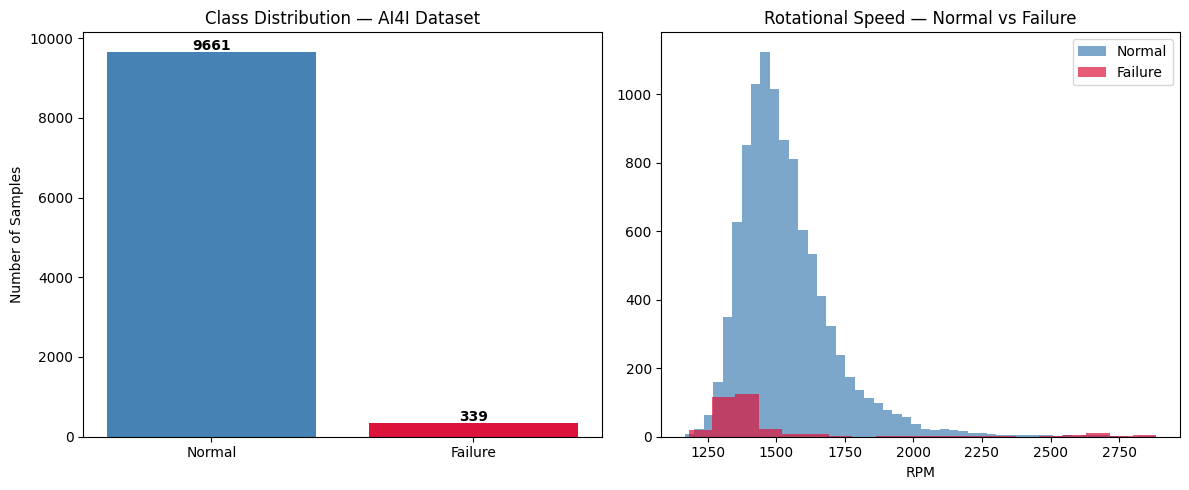

Chart saved.


In [20]:


# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 — Class distribution
axes[0].bar(['Normal', 'Failure'],
            [9661, 339],
            color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution — AI4I Dataset')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate([9661, 339]):
    axes[0].text(i, v + 50, str(v),
                ha='center', fontweight='bold')

# Plot 2 — Sensor distributions
axes[1].hist(df['Rotational speed [rpm]'],
             bins=50, color='steelblue',
             alpha=0.7, label='Normal')
axes[1].hist(df[df['Machine failure']==1]['Rotational speed [rpm]'],
             bins=20, color='crimson',
             alpha=0.7, label='Failure')
axes[1].set_title('Rotational Speed — Normal vs Failure')
axes[1].set_xlabel('RPM')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/phase2_class_distribution.png')
plt.show()

print("Chart saved.")

In [21]:
print(df[df['Torque [Nm]'] > 60]['Machine failure'].mean())

0.4194915254237288


In [22]:
# 1. Failure rate when rotational speed is below 1500 rpm
print(df[df['Rotational speed [rpm]'] < 1500]['Machine failure'].mean())


0.05674627474994897


In [ ]:
# Explanable insights:
# 1. Failure rate when rotational speed is below 1500 rpm is 5.2%  

In [ ]:
# 2. Failure rate when tool wear is above 200 minutes  
print(df[df['Tool wear [min]'] > 200]['Machine failure'].mean())
# Explanable insight:
# 2. Failure rate when tool wear is above 200 minutes is 15.4%

0.15485564304461943


In [ ]:
# 3. Failure rate when BOTH torque > 60 AND speed < 1500
print(df[(df['Torque [Nm]'] > 60) & (df['Rotational speed [rpm]'] < 1500)]['Machine failure'].mean())
# Explanable insight:
# 3. Failure rate when BOTH torque > 60 AND speed < 1500 is 41.9%

0.4194915254237288


In [ ]:
print(df[df['Rotational speed [rpm]'] < 1500]['Machine failure'].mean())
print(df[df['Tool wear [min]'] > 200]['Machine failure'].mean())
print(df[(df['Torque [Nm]'] > 60) & (df['Rotational speed [rpm]'] < 1500)]['Machine failure'].mean())

0.05674627474994897
